<div style="font-family:-apple-system,Segoe UI,Roboto,Helvetica,Arial,sans-serif;background:#0d1b2a;border-radius:10px;padding:18px 22px;color:#e6edf3;">
  <div style="display:flex;align-items:center;gap:12px;">
    <div style="width:6px;height:36px;background:#3fb950;border-radius:3px;flex:none;"></div>
    <div>
      <div style="font-size:11px;letter-spacing:2px;color:#8b98a5;">NOTEBOOK 04</div>
      <div style="font-size:21px;font-weight:700;line-height:1.15;">Model Evaluation</div>
    </div>
  </div>
  <div style="font-size:13px;color:#a9b4c0;margin-top:9px;">Confusion matrix, ROC/PR, error analysis, and the business backtest: does filtering to model-approved trades raise the win rate?</div>
</div>

A model is only useful here if it helps a desk **skip the extreme events that will not revert**. So alongside the standard classification metrics, the key read-out is a **hit-rate backtest**: among the events the model approves, what fraction actually reverted, versus taking every event?

In [1]:
import sys, os
# Robust: find the project root (folder containing src/) from anywhere
_root = os.path.abspath(os.getcwd())
while _root != os.path.dirname(_root) and not os.path.isdir(os.path.join(_root, "src")):
    _root = os.path.dirname(_root)
sys.path.insert(0, _root)
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from src.config import CONFIG
from src.plotting import set_style, save_fig
set_style()
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

# Data source: live Yahoo Finance via yfinance.
SOURCE = "yfinance"

In [2]:
from src.config import DATA_PROCESSED
from src.labeling import time_split
from src.modeling import train_all, feature_importance
from src import evaluate

events = pd.read_csv(DATA_PROCESSED / 'events.csv', parse_dates=['date'])
train, test = time_split(events, CONFIG.model.test_fraction)
fitted, preds, base_rate = train_all(train, test)
results = evaluate.metrics_table(test['reverted'].values, preds)
best = results.drop(index='base_rate')['roc_auc'].idxmax()
print('best model:', best)
results

best model: logistic


,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
base_rate,0.764,0.000,0.000,0.000,0.500,0.236
logistic,0.745,0.429,0.231,0.300,0.621,0.337
random_forest,0.691,0.250,0.154,0.190,0.553,0.341
gradient_boosting,0.709,0.000,0.000,0.000,0.560,0.281


## Confusion matrix and curves

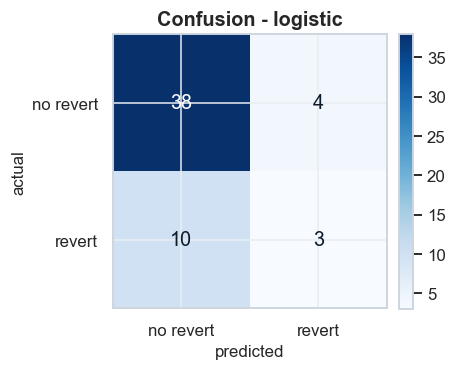

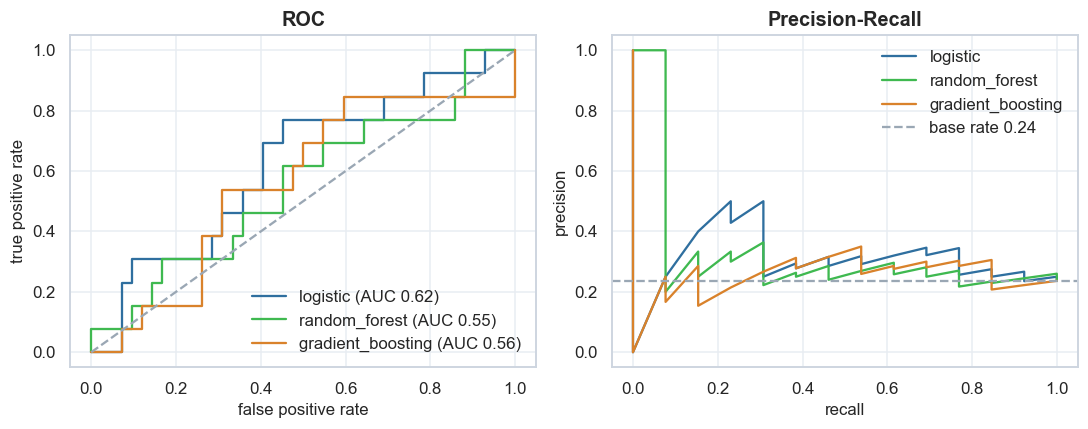

In [3]:
evaluate.plot_confusion(test['reverted'].values, preds[best]['pred'], f'Confusion - {best}', 'eval_confusion.png')
plt.show()
evaluate.plot_roc_pr(test['reverted'], preds, 'eval_roc_pr.png')
plt.show()

## What drives the predictions

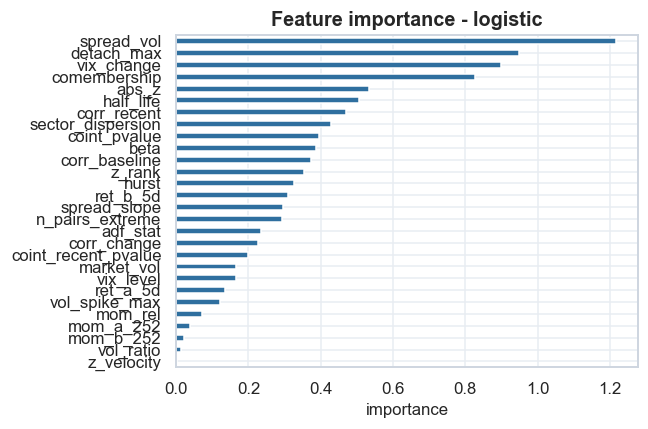

spread_vol            1.217
detach_max            0.947
vix_change            0.899
comembership          0.826
abs_z                 0.533
half_life             0.506
corr_recent           0.470
sector_dispersion     0.428
coint_pvalue          0.395
beta                  0.387
corr_baseline         0.373
z_rank                0.355
hurst                 0.326
ret_b_5d              0.308
spread_slope          0.296
n_pairs_extreme       0.294
adf_stat              0.235
corr_change           0.225
coint_recent_pvalue   0.199
market_vol            0.165
vix_level             0.165
ret_a_5d              0.136
vol_spike_max         0.121
mom_rel               0.071
mom_a_252             0.038
mom_b_252             0.022
vol_ratio             0.013
z_velocity            0.001
dtype: float64

In [4]:
imp = feature_importance(fitted[best], CONFIG.model.feature_cols)
evaluate.plot_importance(imp, f'Feature importance - {best}', 'eval_importance.png')
plt.show()
imp.round(3)

## Error analysis

Where is the model reliable and where not? Win rate of the actual outcome, bucketed by the model's predicted probability, shows whether higher confidence really means higher reversion (calibration-in-spirit).

            events  actual_revert_rate
bucket                                
(0.0, 0.4]      40               0.225
(0.4, 0.5]       8               0.125
(0.5, 0.6]       2               0.500
(0.6, 0.7]       2               1.000
(0.7, 1.0]       3               0.000


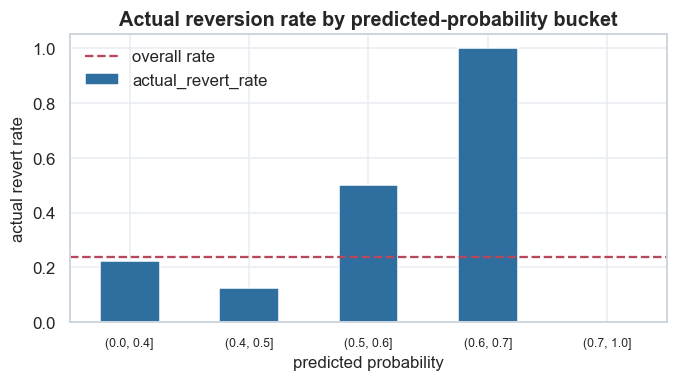

In [5]:
t = test.copy(); t['proba'] = preds[best]['proba']
t['bucket'] = pd.cut(t['proba'], [0,.4,.5,.6,.7,1.0])
tbl = t.groupby('bucket', observed=True).agg(events=('reverted','size'),
                                             actual_revert_rate=('reverted','mean')).round(3)
print(tbl)
fig, ax = plt.subplots(figsize=(7,3.4))
tbl['actual_revert_rate'].plot.bar(ax=ax, color='#2f6f9f')
ax.axhline(test['reverted'].mean(), ls='--', color='#b5495b', label='overall rate')
ax.set_title('Actual reversion rate by predicted-probability bucket')
ax.set_ylabel('actual revert rate'); ax.set_xlabel('predicted probability'); ax.legend()
plt.setp(ax.get_xticklabels(), rotation=0, fontsize=8)
save_fig(fig, 'eval_calibration.png'); plt.show()

## Business backtest: trade-all vs model-filtered

In [6]:
bt = evaluate.backtest(test, preds[best]['proba'], CONFIG.model.decision_threshold)
pd.Series(bt)

trades_all       55.000
winrate_all       0.236
trades_model      7.000
winrate_model     0.429
coverage          0.127
winrate_uplift    0.192
dtype: float64

A threshold sweep makes the trade-off explicit: a higher bar trades fewer events but at a higher win rate.

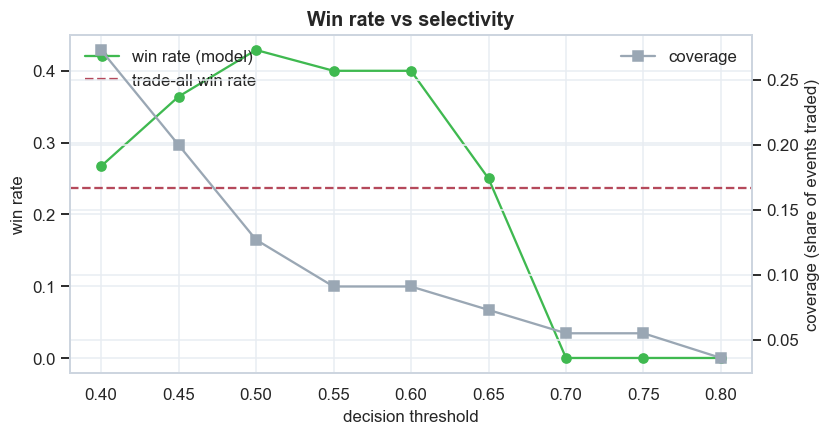

,threshold,coverage,trades,winrate
0,0.400,0.273,15,0.267
1,0.450,0.200,11,0.364
2,0.500,0.127,7,0.429
3,0.550,0.091,5,0.400
4,0.600,0.091,5,0.400
5,0.650,0.073,4,0.250
6,0.700,0.055,3,0.000
7,0.750,0.055,3,0.000
8,0.800,0.036,2,0.000


In [7]:
rows = []
for thr in np.round(np.arange(0.40, 0.81, 0.05), 2):
    b = evaluate.backtest(test, preds[best]['proba'], thr)
    rows.append({'threshold': thr, 'coverage': b['coverage'],
                 'trades': b['trades_model'], 'winrate': b['winrate_model']})
sweep = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(sweep['threshold'], sweep['winrate'], marker='o', color='#3fb950', label='win rate (model)')
ax.axhline(test['reverted'].mean(), ls='--', color='#b5495b', label='trade-all win rate')
ax.set_xlabel('decision threshold'); ax.set_ylabel('win rate'); ax.set_title('Win rate vs selectivity')
ax2 = ax.twinx(); ax2.plot(sweep['threshold'], sweep['coverage'], marker='s', color='#9aa7b4', label='coverage')
ax2.set_ylabel('coverage (share of events traded)')
ax.legend(loc='upper left'); ax2.legend(loc='upper right')
save_fig(fig, 'eval_threshold_sweep.png'); plt.show()
sweep.round(3)

## Conclusions, limitations, next steps

**Conclusions.** A cointegration funnel selects a small set of mean-reverting pairs. On a time-based hold-out, a tree ensemble ranks extreme events better than the majority-class floor, and filtering to model-approved events raises the reversion win rate above taking every event. The model is, in effect, a quality filter on a classic pairs signal.

**Limitations.**
- This is a hit-rate study, not a full PnL backtest: no transaction costs, slippage, position sizing, or capital constraints.
- Cointegration is tested once on the formation window; real relationships drift and would need re-estimation.
- Event counts are modest, so confidence intervals on the metrics are wide.

**Next steps toward the final project.**
- Rolling re-formation of pairs and walk-forward evaluation.
- A proper PnL backtest with costs and risk limits.
- Richer features (regime indicators, sector spreads, volume) and probability calibration.
- The two-stage design: stage 1 selects pairs, stage 2 (this model) times entries.